# Часть 1. Проверка гипотезы в Python и составление аналитической записки

В начале проекта были предобработаны данные в SQL, и теперь они готовы для проверки гипотезы в Python. 

Как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.


## Цели и задачи проекта

<font color='#777778'>Проверка гипотезы, что пользователи Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Рассчитать параметры теста, оценить корректность его проведения. Составить аналитическую записку.</font>

## Описание данных

<font color='#777778'>Таблица `yandex_knigi_data.csv`состоит из полей:
- `city` — наименование города (Москва и Санкт-Петербург);

- `puid` — идентификатор пользователя;

- `hours` — сумма часов активности.
    
    </font>

## Содержимое проекта

<font color='#777778'>
    
    
1. Загрузка данных и знакомство с ними.
    
2. Проверка гипотезы в Python.
    
3. Аналитическая записка.</font>

---

## 1. Загрузка данных и знакомство с ними


In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from scipy import stats as st
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest


In [2]:
# Выгружаем данные в переменную df
df = pd.read_csv('____.csv', low_memory=False, index_col=0)
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [3]:
#Изучим данные датафрейма

def data_overview(df):
    # Вывод первых 5 строк
    display('Первые 5 строк:')
    display(df.head())
    
    # info()
    display('Информация о DataFrame:')
    display(df.info())
    
    # Пропуски абсолютные и относительные
    display('Пропуски:')
    missing = df.isnull().sum()
    display('Абсолютные пропуски:')
    display(missing)
    display('Относительные пропуски:')
    display(missing / len(df) * 100)
    
    # Распределение данных количественных столбцов
    display('Распределение данных количественных столбцов:')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        display(f'{col}:')
        display(df[col].describe())
    
    # Уникальные значения в категориальных столбцах
    display('Уникальные значения в категориальных столбцах:')
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols:
        display(f'{col}:')
        display(df[col].unique())
    
    # Проверка явных дубликатов
    display('Проверка явных дубликатов:')
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        display('Дубликатов нет.')
    else:
        display('Есть дубликаты:')
        display(duplicates)

In [4]:
# Применяем функцию для знакомства с df
# data_overview(df)

In [5]:
#Количество уникальных пользователей
df['puid'].nunique() 

8540

In [6]:
#Количество дубликатов
df.duplicated(subset='puid', keep='last').sum()

244

In [7]:
#Удаление дубликатов
df_clean = df.drop_duplicates(subset='puid', keep='last')

Датафрейм содержит 8540 строк и 3 столбца. Были удалены дубликаты (244). Количество уникальных пользователей 8540.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается. 

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.


In [8]:
# Количество пользователей в каждой из групп 
city_group = df_clean.groupby('city')['puid'].count()
city_group

city
Москва             5990
Санкт-Петербург    2550
Name: puid, dtype: int64

In [9]:
pA = df_clean.loc[df['city'] == 'Москва', 'puid'].count()
pB = df_clean.loc[df['city'] == 'Санкт-Петербург', 'puid'].count()

p = ((pA - pB) / pA) * 100
display(f'Процентная разница в количестве пользователей: {p}')

'Процентная разница в количестве пользователей: 57.42904841402338'

Группа Москва 5990 пользователей, группа Санкт-Петербург 2550. Заметна большая разница между группами в количестве пользователей 57.43%. Сравним средние значения между этими группами.

In [10]:
#Проверим пересечение между группами
city_M = df_clean[df_clean['city'] == 'Москва']['puid']
city_S = df_clean[df_clean['city'] == 'Санкт-Петербург']['puid']

intersection = list(set(city_M) & set(city_S))
count_intersection = len(intersection)
display(count_intersection)
display(intersection)


0

[]

Пересечения не обнаружены.

In [11]:
# Подсчёт дисперсии для группы Москва
variance_M = df[df['city'] == 'Москва']['puid'].var()

# Подсчёт дисперсии для группы Санкт-Петербург
variance_S = df[df['city'] == 'Санкт-Петербург']['puid'].var()

display(variance_M, variance_S)


1.2575055168939104e+28

8.953284290951393e+27

Дисперсия в группе Москва 1.26, Санкт_Петербург 8.95. Так как дисперсии между группами статистически неравны, будем использовать Т-тест Уэлча.

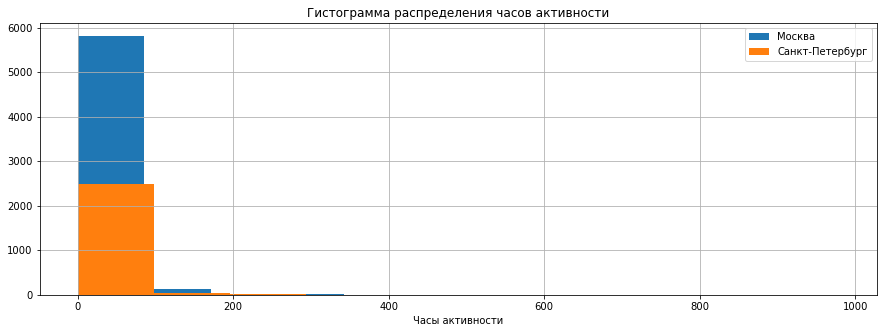

Средняя сумма часов активности для пользователей Москвы 11, а для пользователей Санкт-Петербурга 12


In [12]:
# Гистограмма часов активности для пользователей 
plt.figure(figsize=(15, 5))
df_clean[df_clean.city=='Москва']['hours'].hist(bins=10, label='Москва')
df_clean[df_clean.city=='Санкт-Петербург']['hours'].hist(bins=10, label='Санкт-Петербург')
plt.xlabel('Часы активности')
plt.title('Гистограмма распределения часов активности')
plt.legend()
plt.show()

# Расчет и вывод на экран средней суммы часов активности для пользователей 
mean_M = round(df_clean[df_clean.city=='Москва']['hours'].mean())
mean_S = round(df_clean[df_clean.city=='Санкт-Петербург']['hours'].mean())
print(f'Средняя сумма часов активности для пользователей Москвы {mean_M}, а для пользователей Санкт-Петербурга {mean_S}')

На графике заметна разница в часах активности, но средняя сумма часов активности для пользователей Москвы 11, а для пользователей Санкт-Петербурга 12 говорит об обратном. 

In [13]:

city_S = df_clean[df_clean.city=='Санкт-Петербург']['hours'] # выборка целевой метрики  Санкт-Петербург
city_M = df_clean[df_clean.city=='Москва']['hours'] # выборка целевой метрики  Москва

alpha = 0.05 
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    city_S,
    city_M,
    equal_var=False,
    alternative='greater' # поскольку альтернативная гипотеза о том, что выборочное среднее первой выборки (city_S) больше 
                       # второй выборки (city_М)
) # применяем тест Уэлча 

if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах равны')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах не равны, и в группе Санкт-Петербург больше')

p-value теста Уэлча =0.21
Нулевая гипотеза находит подтверждение! Выборочные средние в группах равны


## 3. Аналитическая записка



1. Для анализа был выбран Т-тест Уэлча, так как группы Москва и Санкт-Петербург имеют существенную разницу 57.43%, дисперсии статистически неравны. Уровень значимости составляет 0.05.
2. p-value теста Уэлча =0.21, а это означает, что нулевая гипотеза находит подтверждение, выборочные средние в группах равны. Статистически значимого различия между группами не обнаружено.
3. Проведенный анализ показывает, что при различии размера выборок выборочные средние значения статистически не различаются. Требуется дальнейшая проверка. 
4. Разница в выборках и статистически неравные дисперсии объясняют полученные результаты. 

# Часть 2. Анализ результатов A/B-тестирования

## 1. Опишите цели исследования.



Провести А/В тестирование двух групп: контрольной и тестовой. У тестовой группы введен новый интерфейс онлайн-магазина. Проверить корректность распределения групп, выбор теста и анализ результатов. 

Нулевая гипотеза, говорит о том что количество пользователей совершавших покупку в группах А и В одинаково. 
Альтернативная гипотеза говорит о том, что количество пользователей совершавших покупку в тестовой группе увеличилось.

## 2. Загрузите данные, оцените их целостность.


In [14]:
participants = pd.read_csv('____.csv')
events = pd.read_csv('____.zip',
                     parse_dates=['event_dt'], low_memory=False)

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [15]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [16]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [17]:
#Проверка пересечения двух тестов
intersection = participants.groupby('user_id').agg({'ab_test':'nunique'}).query('ab_test > 1').index
intersection

Index(['001064FEAAB631A1', '00341D8401F0F665', '0082295A41A867B5',
       '00E68F103C66C1F7', '00EFA157F7B6E1C4', '01B9975CAE144B78',
       '020A95B66F363AFB', '02313B9E82255F47', '02894A55BC14A70E',
       '0363BAFB478AA9EF',
       ...
       'FC3F3E4DA7C85F88', 'FCF70F6E1871BD78', 'FE2AF0E94DBD470E',
       'FE82D7FC50D4155B', 'FE8F9858BBE502D9', 'FEA0C585A53E7027',
       'FEC0BCA6C323872F', 'FF2174A1AA0EAD20', 'FF44696E39039D29',
       'FFF28D02B1EACBE1'],
      dtype='object', name='user_id', length=887)

Обнаружено 887 пользователей, учавствующих в двух тестах.

Самый понятный способ, который гарантирует, что каждый пользователь будет учтён только в одном тесте - удаление. Параллельные эксперименты на одной аудитории могут взаимодействовать и смещать оценки метрик.

In [18]:
#Удалим этих пользователей
filtered_participants = participants[~participants['user_id'].isin(intersection)]
filtered_participants


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
...,...,...,...,...
14518,FFE5B14BD55C1C5C,A,interface_eu_test,PC
14519,FFE600EEC4BA7685,B,interface_eu_test,Android
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC


In [19]:
# Выделим тест 'interface_eu_test' 
test_group_interface = filtered_participants[filtered_participants.ab_test=='interface_eu_test']
test_group_interface

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android
...,...,...,...,...
14518,FFE5B14BD55C1C5C,A,interface_eu_test,PC
14519,FFE600EEC4BA7685,B,interface_eu_test,Android
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC


In [20]:
#равномерность распределения пользователей по группам теста
test_group_interface.groupby('group')['user_id'].nunique()

group
A    4952
B    5011
Name: user_id, dtype: int64

In [21]:
pA = test_group_interface.loc[test_group_interface['group'] == 'A', 'user_id'].nunique()
pB = test_group_interface.loc[test_group_interface['group'] == 'B', 'user_id'].nunique()

p = ((pA - pB) / pA) * 100
display(f'Процентная разница в количестве пользователей в группах A и B: {p}')

'Процентная разница в количестве пользователей в группах A и B: -1.191437802907916'

H₀ (нулевая гипотеза) — количество уникальных пользователей не различается или различия не статистически значимыми между тестовой и контрольной группами.
H₁ (альтернативная гипотеза) — количество уникальных пользователей различается между тестовой и контрольной группами.

In [22]:
# Фильтруем данные для группы A
df_A = test_group_interface[test_group_interface['group'] == 'A'].nunique()
# Фильтруем данные для группы B.
df_B = test_group_interface[test_group_interface['group'] == 'B'].nunique()

# Уровень статистической значимости: можно указать 
alpha = 0.05 

results = st.ttest_ind(
    df_A, 
    df_B,
    alternative='two-sided' 
)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    display('Статистически значимые различия')
else:
    display('Cтатистически не значимые различия')

p-значение: 0.9935869694999577


'Cтатистически не значимые различия'

В ходе анализа было обнаружено, что разница в количестве пользователей между группами составляет 1,5%. 
p_value 0.99, что показывает статистически не значимые различия, не оказывает существенного влияния на результаты эксперимента.

In [23]:
#Проверим пересечение между группами
group_A = test_group_interface[test_group_interface['group'] == 'A']['user_id']
group_B = test_group_interface[test_group_interface['group'] == 'B']['user_id']

intersection = list(set(group_A) & set(group_B))
count_intersection = len(intersection)
display(count_intersection)
display(intersection)

0

[]

Сравним распределение пользователей в граппах по девайсам.

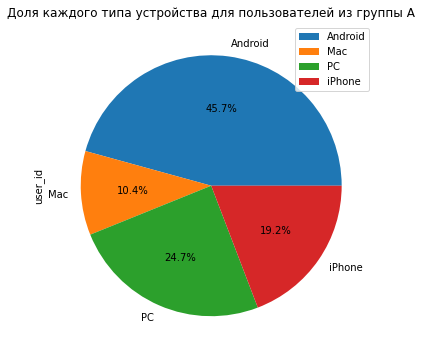

In [24]:
df_A = test_group_interface[test_group_interface['group'] == 'A']

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим круговую диаграмму с помощью pandas через plot(kind='pie')
df_A.groupby('device')['user_id'].nunique().plot(
               kind='pie', # Тип графика - круговая диаграмма
               legend=True, # Включаем легенду
               autopct='%1.1f%%'  # Выводим проценты с одним знаком после запятой
               )

# Настраиваем оформление графика
plt.title('Доля каждого типа устройства для пользователей из группы A')

# Выводим график
plt.show()

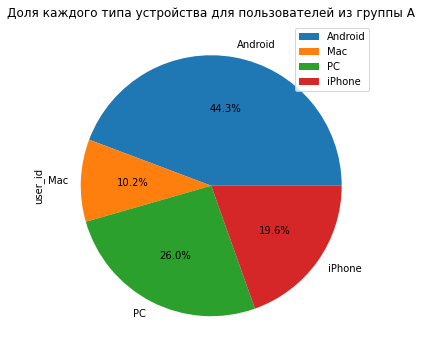

In [25]:
df_B = test_group_interface[test_group_interface['group'] == 'B']

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим круговую диаграмму с помощью pandas через plot(kind='pie')
df_B.groupby('device')['user_id'].nunique().plot(
               kind='pie', # Тип графика - круговая диаграмма
               legend=True, # Включаем легенду
               autopct='%1.1f%%'  # Выводим проценты с одним знаком после запятой
               )

# Настраиваем оформление графика
plt.title('Доля каждого типа устройства для пользователей из группы A')

# Выводим график
plt.show()

Распределение групп по девайсам равномерно.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [26]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [27]:
# Применяем функцию для знакомства с df
# data_overview(events)

В датафрейме `events` было обнаружено 36318 дубликата. Удалим их.

In [28]:
events.drop_duplicates(subset=None, keep='first')

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
...,...,...,...,...
787281,1A655C280B064708,2020-12-31 23:57:44,product_page,NaN
787282,B77B2F4BCA134618,2020-12-31 23:58:23,registration,0.0
787283,GLOBAL,2020-12-31 23:58:30,product_cart,NaN
787284,B12AD1623E494FAD,2020-12-31 23:58:34,registration,-6.52


In [29]:
# Соединим два датафрейма с колонкой 'user_id'
df_test = events.merge(test_group_interface, on='user_id', how='inner')

df_test.head()

,user_id,event_dt,event_name,details,group,ab_test,device
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,A,interface_eu_test,iPhone
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,A,interface_eu_test,iPhone
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,A,interface_eu_test,iPhone
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,A,interface_eu_test,iPhone


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [30]:

# Найдем дату регистрации 'user_id'
registration_dates = df_test[df_test['event_name'] == 'registration'].groupby('user_id')['event_dt'].min()

# Объединяем даты регистрации с основным датафреймом
df_test = df_test.merge(registration_dates, on='user_id', how='left', suffixes=['', '_registration'])

# Фильтруем события, которые произошли в течение первых семи дней
filtered_df = df_test[(df_test['event_dt'] >= df_test['event_dt_registration']) & 
                      (df_test['event_dt'] <= df_test['event_dt_registration'] + pd.to_timedelta('7D'))]

filtered_df.head()

,user_id,event_dt,event_name,details,group,ab_test,device,event_dt_registration
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,A,interface_eu_test,iPhone,2020-12-06 14:10:01
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,A,interface_eu_test,iPhone,2020-12-06 14:10:01


Посмотрим, как распределены суммы на стоимость привлечения клиентов и стоимость покупкок.

In [31]:
reg_pur_df = filtered_df.copy()
reg_pur_df.loc[:, 'details'] = pd.to_numeric(filtered_df['details'], errors='coerce')
registr = reg_pur_df[reg_pur_df['event_name'] == 'registration'].groupby('group')['details'].sum()
registr


group
A   -10133.11
B   -10481.71
Name: details, dtype: float64

In [32]:
reg_pur_df.loc[:, 'details'] = pd.to_numeric(filtered_df['details'], errors='coerce')
purchase_sum = reg_pur_df[reg_pur_df['event_name'] == 'purchase'].groupby('group')['details'].sum()
purchase_sum

group
A    75579.40
B    82545.28
Name: details, dtype: float64

Стоимость привлечения клиентов в группах A (-10133,11) и B (-10481,71) имеет близкие значения. Разница между показателями составляет примерно 348,6, что является незначительным.

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [33]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый показатель конверсии
mde = 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

display(f'Необходимый размер выборки для каждой группы: {sample_size}')

'Необходимый размер выборки для каждой группы: 3761.596974012117'

In [34]:
pA = filtered_df.loc[filtered_df['group'] == 'A', 'user_id'].nunique()
pB = filtered_df.loc[filtered_df['group'] == 'B', 'user_id'].nunique()

p = ((pA - pB) / pA) * 100
display(f'Процентная разница в количестве пользователей в группах A и B: {p}')

'Процентная разница в количестве пользователей в группах A и B: -1.191437802907916'

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [35]:
total_users_A = filtered_df[filtered_df['group'] == 'A']['user_id'].nunique()
buy_users_A = filtered_df[(filtered_df['group'] == 'A')&(filtered_df['event_name']=='purchase')]['user_id'].nunique()
share_A = buy_users_A/total_users_A*100
display(f'Общее количество в группе А {total_users_A}, совершивших покупок {buy_users_A},' 
        f'доля совершивших покупку в группе А {share_A}')

'Общее количество в группе А 4952, совершивших покупок 1377,доля совершивших покупку в группе А 27.806946688206786'

In [36]:
total_users_B = filtered_df[filtered_df['group'] == 'B']['user_id'].nunique()
buy_users_B = filtered_df[(filtered_df['group'] == 'B')&(filtered_df['event_name']=='purchase')]['user_id'].nunique()
share_B = buy_users_B/total_users_B*100
display(f'Общее количество в группе B {total_users_B}, совершивших покупок {buy_users_B},' 
        f'доля совершивших покупку в группе B {share_B}')

'Общее количество в группе B 5011, совершивших покупок 1480,доля совершивших покупку в группе B 29.535022949511074'

In [37]:
absolut = round(share_B-share_A,2)
otnos = round(((share_B/share_A)-1)*100,2)
display(f'Абсолютная разница {absolut}, относительный прирост {otnos}')

'Абсолютная разница 1.73, относительный прирост 6.21'

Заложено тестом прирост 3 %, но прирост показал 6,21 %. 

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Группа В показывает большее количество покупателей, чем группа А. Количество пользователей совершивших покупки группа А 1377, группа В 1480. 

## 4. Проведите оценку результатов A/B-тестирования:

Данные независимы, посмотрим на достаточное количество выборок.

Нулевая гипотеза, говорит о том что количество пользователей совершавших покупку в группах А и В одинаково. pA=pB

Альтернативная гипотеза говорит о том, что количество пользователей совершавших покупку в тестовой группе увеличилось. pA<pB

In [38]:
# Размер группы A
n_a = filtered_df[filtered_df.group== 'A'].shape[0] 

# Размер группы B
n_b = filtered_df[filtered_df.group == 'B'].shape[0]

# Количество успехов в группе A
m_a = filtered_df[(filtered_df.group=='A')&(filtered_df.event_name=='purchase')].shape[0] 

# Количество успехов в группе B
m_b = filtered_df[(filtered_df.group=='B')&(filtered_df.event_name=='purchase')].shape[0]

p_a, p_b =  m_a/n_a, m_b/n_b # доли успехов для каждой группы: A и B 

# Вычисляем разницу в доле успешных сессий между группами A и B
difference = (p_a- p_b)*100

# Отображаем результаты
display(f"Доля успешных сессий для группы A: {p_a}")
display(f"Доля успешных сессий для группы B: {p_b}")
display(f"Разница в доле успешных сессий: {difference}")

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10): # проверка предпосылки о достаточном количестве данных
    display('Предпосылка о достаточном количестве данных выполняется!')
else:
    display('Предпосылка о достаточном количестве данных НЕ выполняется!')

'Доля успешных сессий для группы A: 0.08636131013306039'

'Доля успешных сессий для группы B: 0.10638886328016964'

'Разница в доле успешных сессий: -2.0027553147109245'

'Предпосылка о достаточном количестве данных выполняется!'

Разница в доле успешных сессий 2 %. Доля успешных сессий в одной из групп выше, это может говорить о том, что изменения, протестированные в этой группе, положительно повлияли на пользовательский опыт. А значит, они могут быть внедрены в основную версию продукта.

Предпосылка о достаточном количестве данных выполняется, проведем Z-тест, так как поверяем гипотезу pA<pB выбираем 'smaller'.

In [39]:
alpha =  0.05 ## уровень значимости


stat_ztest, p_value_ztest = proportions_ztest( # Z-тест пропорций
	[m_a, m_b],
    [n_a, n_b],
	alternative= 'smaller'
)

print(f'pvalue={p_value_ztest}') # полученное p-value 

if p_value_ztest > alpha:
    display('Нулевая гипотеза находит подтверждение!')
else:
    display('Нулевая гипотеза не находит подтверждения!')

pvalue=5.5618798640599e-18


'Нулевая гипотеза не находит подтверждения!'

На основе проведенного теста А/В - теста альтернативная гипотеза подтверждается, что доказывает почти нулевое значение p-value. Это означает, что вероятность того, что разница в 1.73 между группами по случайности практически равна нулю. Внедренное изменение в варианте В привело к статистически значимому росту конверсии в покупку по сравнению с контрольной группой. 
Конверсия в группе А 27.81 %, в группе В 29.54 %, абсолютный прирост +1.73%, относительный прирост +6.21%.
Полученный относительный прирост конверсии на 6% превышает запланированный порог MDE 3% и имеет высокую ценность.
Уровень значимости в данном тесте 0.05, мощность теста 80%, конверсия 30%.

Стоить принять изменение в интерфейсе онлайн-магазина, так как тестирование в группе В доказало свою эффективность для увеличения ключевой метрики.